# LabSheet - 6
### Name - Saurabh Kumar Jha
### CUID - CU24250005
### Program - B.Tech - CSE

In [4]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [5]:
image_path = "test.png" 
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [6]:

# 1. Global Thresholding
_, global_threshold = cv2.threshold(
    blurred, 127, 255, cv2.THRESH_BINARY
)

In [7]:

# 2. Otsu's Thresholding
otsu_value, otsu_threshold = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)


In [8]:

# 3. Adaptive Thresholding
adaptive_threshold = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
     blockSize=11,
    C=2
)

In [9]:

# 4. Watershed Segmentation
_, binary = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

sure_background = cv2.dilate(opening, kernel, iterations=3)
distance = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_foreground = cv2.threshold(
    distance, 0.5 * distance.max(), 255, 0
)
sure_foreground = np.uint8(sure_foreground)

unknown = cv2.subtract(sure_background, sure_foreground)

_, markers = cv2.connectedComponents(sure_foreground)
markers = markers + 1
markers[unknown == 255] = 0

watershed_image = image.copy()
markers = cv2.watershed(watershed_image, markers)
watershed_image[markers == -1] = [255, 0, 0]
watershed_rgb = cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB)


In [10]:

# 5. K-Means Color Segmentation
pixels = image_rgb.reshape((-1, 3)).astype(np.float32)
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
centers = np.uint8(kmeans.cluster_centers_)

kmeans_result = centers[labels].reshape(image_rgb.shape)


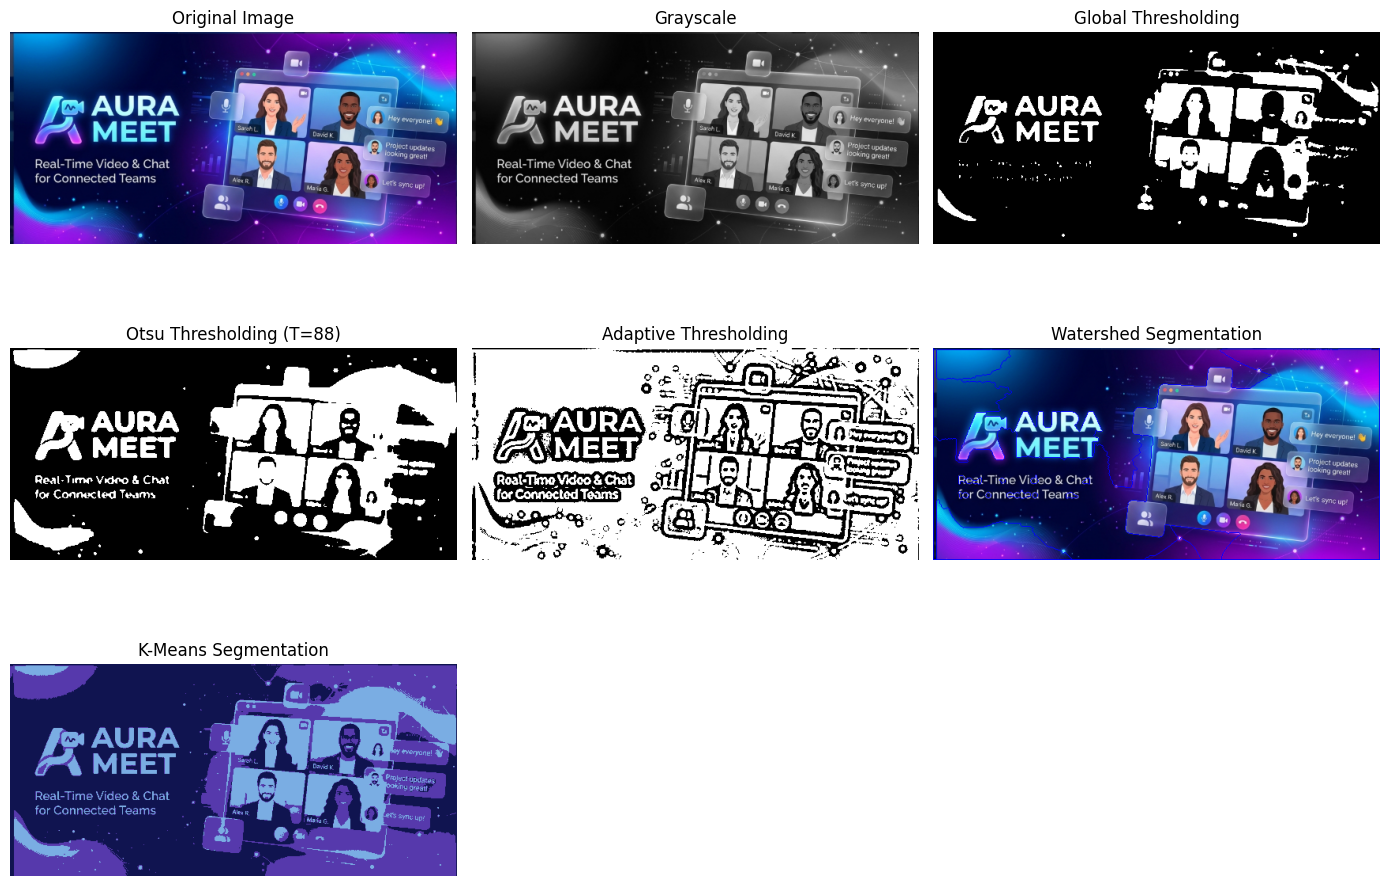

In [11]:

# Display results
results = [
    ("Original Image", image_rgb),
    ("Grayscale", gray),
    ("Global Thresholding", global_threshold),
    (f"Otsu Thresholding (T={otsu_value:.0f})", otsu_threshold),
    ("Adaptive Thresholding", adaptive_threshold),
    ("Watershed Segmentation", watershed_rgb),
    ("K-Means Segmentation", kmeans_result),
]

plt.figure(figsize=(14, 10))

for index, (title, result) in enumerate(results, start=1):
    plt.subplot(3, 3, index)
    if len(result.shape) == 2:
        plt.imshow(result, cmap="gray")
    else:
        plt.imshow(result)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()